# Ingeniería de variables

Se generarán variables relacionadas con la fatiga a partir de datos históricos de votaciones a lo largo de las carreras de los jugadores.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('datos_1980-2025_procesados.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       2006 non-null   float64
 1   MP        2006 non-null   float64
 2   PER       2006 non-null   float64
 3   TS%       2006 non-null   float64
 4   FTr       2006 non-null   float64
 5   TRB%      2006 non-null   float64
 6   AST%      2006 non-null   float64
 7   STL%      2006 non-null   float64
 8   USG%      2006 non-null   float64
 9   W/L%      2006 non-null   float64
 10  Share     2006 non-null   float64
 11  Season    2006 non-null   int64  
 12  MVP_Rank  2006 non-null   int64  
 13  Awards    2006 non-null   object 
 14  Player    2006 non-null   object 
 15  Team      2006 non-null   object 
dtypes: float64(11), int64(2), object(3)
memory usage: 250.9+ KB


In [ ]:
def rank_to_score(rank):
    if rank == 0 or rank > 15: return 0.0  # Los votos marginales no generan fatiga
    return 1.0 / rank

def get_streak_weight(rank):
    if rank == 1: return 1.0      # Ganador: Fatiga máxima
    if 2 <= rank <= 3: return 0.5  # Podio: Fatiga alta
    if 4 <= rank <= 5: return 0.25 # Top 5: Fatiga moderada
    return 0.0

def calculate_advanced_fatigue(df, decay=0.5):
    df = df.sort_values(['Player', 'Season']).reset_index(drop=True)

    df['prominence_score'] = df['MVP_Rank'].apply(rank_to_score)

    fatigue_decay = []
    fatigue_streak = []
    is_defending_mvp = []

    for player, group in df.groupby('Player'):
        prom = group['prominence_score'].values
        ranks = group['MVP_Rank'].values
        seasons = group['Season'].values

        f_dec = [0.0]
        f_str = [0]
        def_mvp = [0]

        for i in range(1, len(group)):
            # Temporadas consecutivas (evitar problemas con semi-retiradas como Jordan)
            is_consecutive = (seasons[i] == seasons[i-1] + 1)

            if is_consecutive:
                past_prom = prom[:i]
                weights = decay ** np.arange(len(past_prom)-1, -1, -1)
                f_dec.append(np.dot(weights, past_prom))

                last_streak = f_str[-1]
                # Fuera del top 5 se resetea
                weight = get_streak_weight(ranks[i-1])
                if weight > 0:
                    f_str.append(last_streak + weight)
                else:
                    f_str.append(0.0)

                def_mvp.append(1 if ranks[i-1] == 1 else 0)

            else:
                f_str.append(0)
                def_mvp.append(0)

                gap_years = seasons[i] - seasons[i-1]
                past_prom = prom[:i]
                weights = decay ** (np.arange(len(past_prom)-1, -1, -1) + (gap_years - 1))
                f_dec.append(np.dot(weights, past_prom))

        fatigue_decay.extend(f_dec)
        fatigue_streak.extend(f_str)
        is_defending_mvp.extend(def_mvp)

    df['fatigue_decay'] = fatigue_decay
    df['fatigue_streak'] = fatigue_streak
    df['is_defending_mvp'] = is_defending_mvp

    return df

In [ ]:
df2 = calculate_advanced_fatigue(df)

In [ ]:
df2.sort_values('Season')

,Age,MP,PER,TS%,FTr,TRB%,AST%,STL%,USG%,W/L%,Share,Season,MVP_Rank,Awards,Player,Team,prominence_score,fatigue_decay,fatigue_streak,is_defending_mvp
2,24.0,2674.0,24.3,0.635,0.415,11.3,12.3,1.8,27.8,0.293,0.000,1980,0,AS,Adrian Dantley,UTA,0.0,0.0,0.0,0
1,25.0,1286.0,18.7,0.563,0.361,11.5,11.6,1.5,24.6,0.463,0.000,1980,0,No awards,Abdul Jeelani,POR,0.0,0.0,0.0,0
60,25.0,2168.0,19.2,0.571,0.270,15.4,21.6,2.3,21.9,0.671,0.000,1980,0,No awards,Alvan Adams,PHO,0.0,0.0,0.0,0
1597,25.0,2582.0,21.6,0.546,0.306,8.7,28.5,2.9,27.2,0.476,0.000,1980,0,No awards,Ray Williams,NYK,0.0,0.0,0.0,0
1009,29.0,2812.0,25.4,0.568,0.331,10.9,21.4,2.8,30.3,0.720,0.143,1980,2,"MVP-2,AS,NBA1",Julius Erving,PHI,0.5,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,27.0,2674.0,18.9,0.561,0.295,15.5,20.0,1.8,23.5,0.451,0.000,2025,0,DPOY-10,Bam Adebayo,MIA,0.0,0.0,0.0,0
1286,29.0,1361.0,19.6,0.683,0.346,15.5,11.9,1.3,11.4,0.744,0.000,2025,0,No awards,Luke Kornet,BOS,0.0,0.0,0.0,0
59,22.0,2395.0,21.4,0.545,0.374,17.5,24.1,1.7,26.2,0.634,0.000,2025,0,AS,Alperen Şengün,HOU,0.0,0.0,0.0,0
1490,34.0,2278.0,20.3,0.611,0.144,16.9,17.1,1.2,22.4,0.476,0.000,2025,0,No awards,Nikola Vučević,CHI,0.0,0.0,0.0,0


In [ ]:
# Vemos datos de df2 solo para el jugador LeBron James ordenados por Season
df2[df2['Player'] == 'LeBron James'].sort_values('Season')

,Age,MP,PER,TS%,FTr,TRB%,AST%,STL%,USG%,W/L%,Share,Season,MVP_Rank,Awards,Player,Team,prominence_score,fatigue_decay,fatigue_streak,is_defending_mvp
1248,19.0,3122.0,18.3,0.488,0.308,7.6,27.8,2.2,28.2,0.427,0.009,2004,9,"MVP-9,ROY-1",LeBron James,CLE,0.111111,0.000000,0.00,0
1249,20.0,3388.0,25.7,0.554,0.378,10.2,32.9,2.8,29.7,0.512,0.073,2005,6,"MVP-6,AS,NBA2",LeBron James,CLE,0.166667,0.111111,0.00,0
1250,21.0,3361.0,28.1,0.568,0.447,9.8,32.8,2.0,33.6,0.610,0.550,2006,2,"MVP-2,AS,NBA1",LeBron James,CLE,0.500000,0.222222,0.00,0
1251,22.0,3190.0,24.5,0.552,0.432,9.6,29.1,2.1,31.0,0.610,0.142,2007,5,"MVP-5,AS,NBA2",LeBron James,CLE,0.200000,0.611111,0.50,0
1252,23.0,3027.0,29.1,0.568,0.470,11.1,37.3,2.4,33.5,0.549,0.348,2008,4,"MVP-4,AS,NBA1",LeBron James,CLE,0.250000,0.505556,0.75,0
1253,24.0,3054.0,31.7,0.591,0.472,11.9,38.0,2.4,33.8,0.805,0.969,2009,1,"MVP-1,DPOY-2,AS,NBA1,DEF1",LeBron James,CLE,1.000000,0.502778,1.00,0
1254,25.0,2966.0,31.1,0.604,0.506,11.1,41.8,2.2,33.5,0.744,0.980,2010,1,"MVP-1,DPOY-4,AS,NBA1,DEF1",LeBron James,CLE,1.000000,1.251389,2.00,1
1255,26.0,3063.0,27.3,0.594,0.446,11.4,34.9,2.1,31.5,0.707,0.431,2011,3,"MVP-3,DPOY-9,AS,NBA1,DEF1",LeBron James,MIA,0.333333,1.625694,3.00,1
1256,27.0,2326.0,30.7,0.605,0.429,12.6,33.6,2.6,32.0,0.697,0.888,2012,1,"MVP-1,DPOY-4,AS,NBA1,DEF1",LeBron James,MIA,1.000000,1.146181,3.50,0
1257,28.0,2877.0,31.6,0.640,0.395,13.1,36.4,2.4,30.2,0.805,0.998,2013,1,"MVP-1,DPOY-2,AS,NBA1,DEF1",LeBron James,MIA,1.000000,1.573090,4.50,1


In [ ]:
correlation_matrix = df2[['fatigue_decay', 'fatigue_streak', 'is_defending_mvp', 'Share']].corr()
display(correlation_matrix['Share']) # Correlación de nuevas variables de fatiga con el Share

,Share
fatigue_decay,0.629474
fatigue_streak,0.492271
is_defending_mvp,0.414455
Share,1.000000


## Visualización de datos generados de fatiga

Comparativa de fatiga sobre un caso concreto, el de LeBron James.

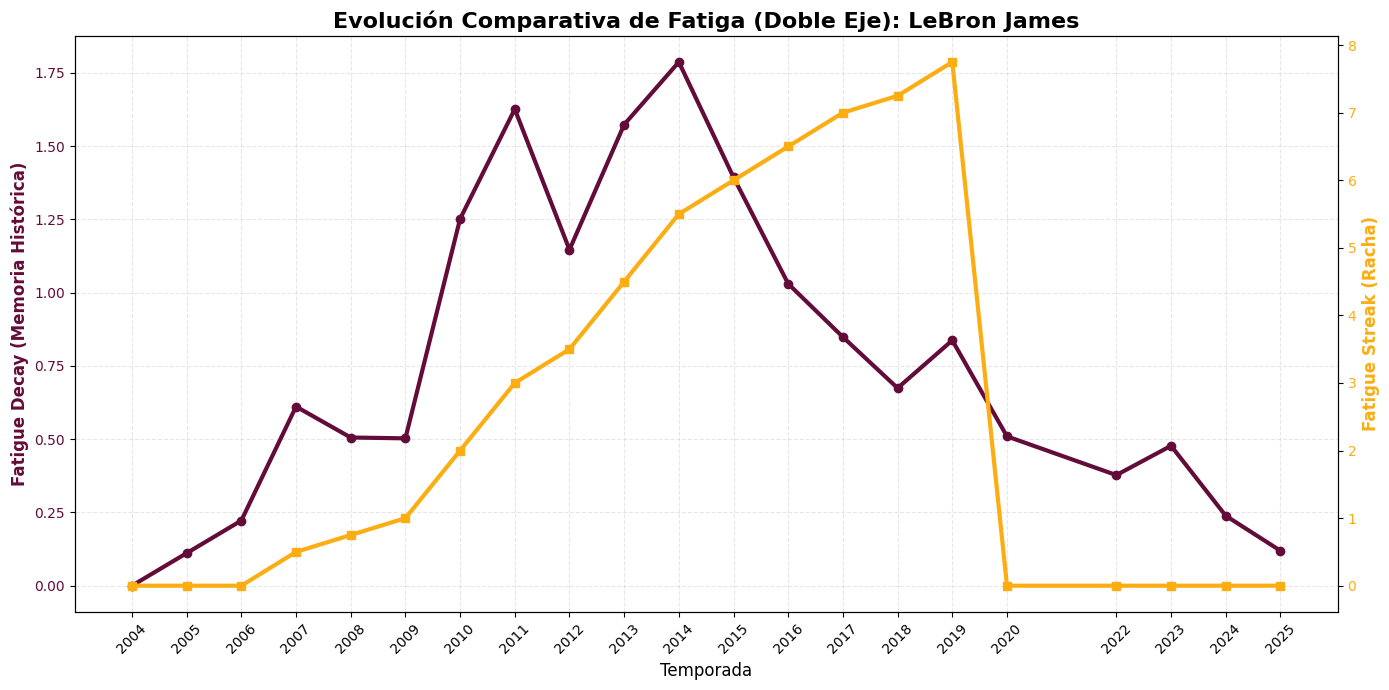

In [ ]:
lebron_data = df2[df2['Player'] == 'LeBron James'].sort_values('Season')

fig, ax1 = plt.subplots(figsize=(14, 7))

# Primer eje (Izquierdo) para Fatigue Decay
color_decay = '#630C3A'
ax1.set_xlabel('Temporada', fontsize=12)
ax1.set_ylabel('Fatigue Decay (Memoria Histórica)', color=color_decay, fontsize=12, fontweight='bold')
ax1.plot(lebron_data['Season'], lebron_data['fatigue_decay'], marker='o', linewidth=3, color=color_decay, label='Fatigue Decay')
ax1.tick_params(axis='y', labelcolor=color_decay)
ax1.grid(True, linestyle='--', alpha=0.3)

# Segundo eje (Derecho) para Fatigue Streak
ax2 = ax1.twinx()
color_streak = '#FCAD12'
ax2.set_ylabel('Fatigue Streak (Racha)', color=color_streak, fontsize=12, fontweight='bold')
ax2.plot(lebron_data['Season'], lebron_data['fatigue_streak'], marker='s', linewidth=3, color=color_streak, label='Fatigue Streak')
ax2.tick_params(axis='y', labelcolor=color_streak)

# Configuración final
plt.title('Evolución Comparativa de Fatiga (Doble Eje): LeBron James', fontsize=16, fontweight='bold')
ax1.set_xticks(lebron_data['Season'])
ax1.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

Comparativa de evolución de fatiga entre dos jugadores, LeBron James y Michael Jordan.

Gráfico guardado como 'comparativa_lebron_jordan.png'


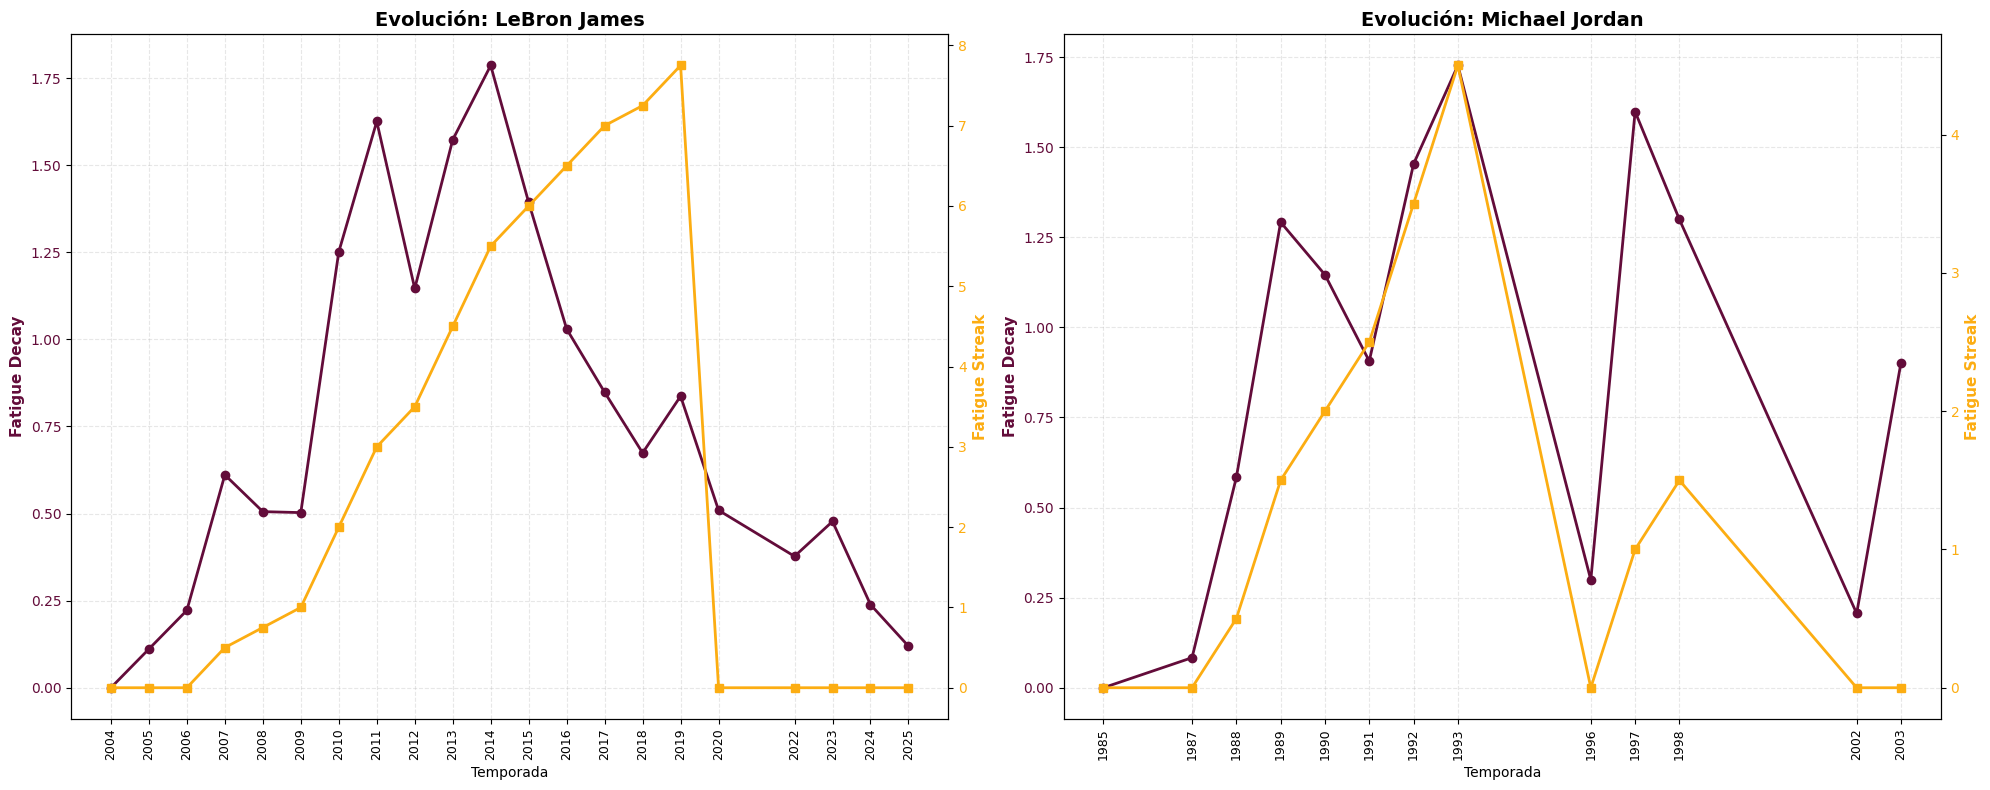

In [ ]:
def plot_player_fatigue(ax, player_name, df):
    data = df[df['Player'] == player_name].sort_values('Season')

    # Eje Izquierdo: Decay
    color_decay = '#630C3A'
    ax.set_xlabel('Temporada', fontsize=10)
    ax.set_ylabel('Fatigue Decay', color=color_decay, fontsize=11, fontweight='bold')
    ax.plot(data['Season'], data['fatigue_decay'], marker='o', linewidth=2, color=color_decay, label='Decay')
    ax.tick_params(axis='y', labelcolor=color_decay)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Eje Derecho: Streak
    ax2 = ax.twinx()
    color_streak = '#FCAD12'
    ax2.set_ylabel('Fatigue Streak', color=color_streak, fontsize=11, fontweight='bold')
    ax2.plot(data['Season'], data['fatigue_streak'], marker='s', linewidth=2, color=color_streak, label='Streak')
    ax2.tick_params(axis='y', labelcolor=color_streak)

    ax.set_title(f'Evolución: {player_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(data['Season'])
    ax.tick_params(axis='x', rotation=90, labelsize=9)

# Crear figura con 1 fila y 2 columnas (lado a lado)
fig, (ax_lebron, ax_jordan) = plt.subplots(1, 2, figsize=(20, 8))

plot_player_fatigue(ax_lebron, 'LeBron James', df2)
plot_player_fatigue(ax_jordan, 'Michael Jordan', df2)

plt.tight_layout()

plt.savefig('comparativa_lebron_jordan.png', dpi=300)
print("Gráfico guardado como 'comparativa_lebron_jordan.png'")

plt.show()

Gráfico para ver distribución de qué posición ocupa cada jugador la temporada inmediatamente después de ganar el MVP.

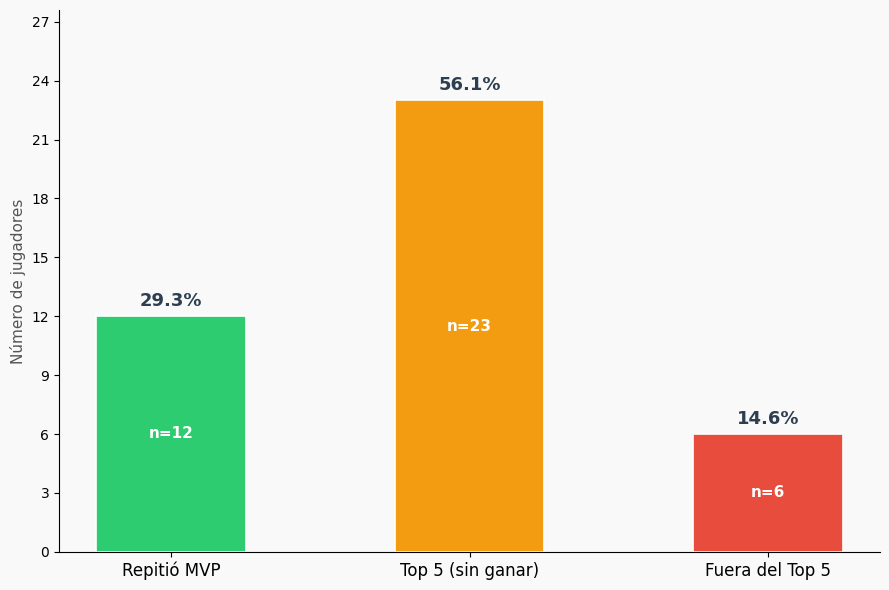

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

mvps = df[df['MVP_Rank'] == 1][['Season', 'Player']].sort_values('Season').reset_index(drop=True)

categorias = {'Repitió MVP': 0, 'Top 5 (sin ganar)': 0, 'Fuera del Top 5': 0}

for _, row in mvps.iterrows():
    jugador = row['Player']
    siguiente_temporada = row['Season'] + 1

    siguiente = df[(df['Season'] == siguiente_temporada) & (df['Player'] == jugador)]

    if siguiente.empty:
        continue

    rank = siguiente.iloc[0]['MVP_Rank']

    if rank == 1:
        categorias['Repitió MVP'] += 1
    elif 2 <= rank <= 5:
        categorias['Top 5 (sin ganar)'] += 1
    else:
        categorias['Fuera del Top 5'] += 1

total = sum(categorias.values())
labels = list(categorias.keys())
valores = list(categorias.values())
porcentajes = [v / total * 100 for v in valores]

colores = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(labels, valores, color=colores, edgecolor='white', linewidth=1.2, width=0.5)

for bar, pct in zip(bars, porcentajes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#2c3e50'
    )

for bar, val in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'n={val}',
        ha='center', va='center',
        fontsize=11, color='white', fontweight='bold'
    )

ax.set_ylabel('Número de jugadores', fontsize=11, color='#555')
ax.set_ylim(0, max(valores) * 1.2)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('mvp_siguiente_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df2['fatigue_decay'].describe()

,fatigue_decay
count,2006.000000
mean,0.112618
std,0.266520
min,0.000000
25%,0.000000
50%,0.000000
75%,0.085069
max,1.863281


In [ ]:
df2.to_csv('datos_1980-2025_procesados_fatigue.csv', index=False)

In [ ]:
finalidad_map = {
    'Player': 'Control (Identificador)',
    'Team': 'Control (Identificador)',
    'Season': 'Control (Temporal)',
    'Age': 'Predicción (Bio)',
    'PER': 'Predicción (Rendimiento)',
    'TS%': 'Predicción (Eficiencia)',
    'FTr': 'Predicción (Estilo)',
    'TRB%': 'Predicción (Rebotes)',
    'AST%': 'Predicción (Asistencias)',
    'STL%': 'Predicción (Defensa)',
    'USG%': 'Predicción (Carga)',
    'W/L%': 'Predicción (Éxito Equipo)',
    'Share': 'Variable Objetivo (Votos)',
    'MVP_Rank': 'Control (Resultado)',
    'Awards': 'Control (Historial)',
    'prominence_score': 'Predicción (Impacto)',
    'fatigue_decay': 'Predicción (Fatiga Acumulada)',
    'fatigue_streak': 'Predicción (Fatiga Racha)',
    'is_defending_mvp': 'Predicción (Estatus Defensor)'
}

resumen_data = []
for col in df2.columns:
    col_min = df2[col].min() if df2[col].dtype != 'object' else 'N/A'
    col_max = df2[col].max() if df2[col].dtype != 'object' else 'N/A'

    resumen_data.append({
        'Variable': col,
        'Finalidad': finalidad_map.get(col, 'Predicción'),
        'Rango': f'[{col_min}, {col_max}]' if col_min != 'N/A' else 'Texto/Categórico'
    })

df_resumen = pd.DataFrame(resumen_data)
display(df_resumen)

,Variable,Finalidad,Rango
0,Age,Predicción (Bio),"[19.0, 40.0]"
1,MP,Predicción,"[469.0, 3485.0]"
2,PER,Predicción (Rendimiento),"[18.0, 32.8]"
3,TS%,Predicción (Eficiencia),"[0.468, 0.745]"
4,FTr,Predicción (Estilo),"[0.101, 1.219]"
5,TRB%,Predicción (Rebotes),"[2.4, 29.6]"
6,AST%,Predicción (Asistencias),"[1.4, 57.5]"
7,STL%,Predicción (Defensa),"[0.4, 4.8]"
8,USG%,Predicción (Carga),"[10.1, 41.7]"
9,W/L%,Predicción (Éxito Equipo),"[0.146, 0.89]"
